# 1. Exploratory Data Analysis (EDA)

**Research Question:** Does the daily volume of AI research publications on arXiv carry any predictive signal for the BOTZ ETF's financial performance?

This notebook follows a structured analytical pipeline:

1. **Univariate Analysis** — understand each variable independently before comparing them.
2. **Bivariate Analysis** — explore visual and statistical relationships.
3. **Spurious Correlation Check** — test whether the observed correlation is real or trend-driven.

> **Key Methodological Warning (read before interpreting results):** Both AI paper counts and the BOTZ ETF price have generally trended upward from 2016 to 2023. Any correlation between two variables that share a common upward trend is potentially *spurious* — it may reflect nothing more than the passage of time. This notebook identifies where that risk is highest and flags it explicitly.

## 0. Setup & Configuration

All imports and shared constants are declared here so any cell can be re-run independently.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# ── Shared constants ──────────────────────────────────────────────────────────
DATE_START = '2016-09-01'
DATE_END   = '2023-12-31'
ROLLING_WINDOW = 30        # days for smoothing

# ── Colour palette (consistent across all plots) ──────────────────────────────
C_ETF    = '#1f77b4'   # steel blue  → BOTZ price / returns
C_PAPER  = '#ff7f0e'   # safety orange → paper counts
C_TREND  = '#d62728'   # red          → regression / moving average
C_ACCENT = '#2ca02c'   # green        → secondary annotations

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Setup complete.')

Setup complete.


## 1.1 Data Loading & Validation

We load the pre-built master dataset that already aligns arXiv submissions with trading-day dates (weekend papers are forward-filled to Monday). Before any analysis, we run a basic data-quality checklist.

In [2]:
df = (
    pd.read_csv('ai_market_master_dataset.csv', parse_dates=['date'])
      .set_index('date')
      .loc[DATE_START:DATE_END]
      .copy()
)

# Derived columns used throughout the notebook
df['paper_ma30']   = df['paper_count'].rolling(ROLLING_WINDOW, min_periods=1).mean()
df['log_paper']    = np.log1p(df['paper_count'])          # log(1+x) handles zeros safely
df['return_sign']  = np.sign(df['daily_return'])          # direction: +1, 0, -1
df['abs_return']   = df['daily_return'].abs()             # volatility proxy

# ── Data quality checklist ────────────────────────────────────────────────────
print('═' * 50)
print('DATA QUALITY CHECKLIST')
print('═' * 50)
print(f'Rows (trading days)  : {len(df):,}')
print(f'Date range           : {df.index.min().date()} → {df.index.max().date()}')
print(f'Missing values       :')
print(df.isnull().sum().to_string(header=False))
print(f'Days with 0 papers   : {(df["paper_count"] == 0).sum()}')
print(f'Days with |return|>5%: {(df["abs_return"] > 0.05).sum()}')
print('═' * 50)

══════════════════════════════════════════════════
DATA QUALITY CHECKLIST
══════════════════════════════════════════════════
Rows (trading days)  : 1,836
Date range           : 2016-09-14 → 2023-12-29
Missing values       :
price           0
daily_return    0
paper_count     0
paper_ma30      0
log_paper       0
return_sign     0
abs_return      0
Days with 0 papers   : 0
Days with |return|>5%: 21
══════════════════════════════════════════════════


## 1.2 Descriptive Statistics

Summary statistics for both variables. Pay attention to:
- **Skewness** of paper counts: large positive skew means a few extreme submission days pull the mean far above the median.
- **Kurtosis** of daily returns: excess kurtosis (>3) is the statistical fingerprint of *fat tails* — extreme market moves happen more often than a normal distribution predicts. This is a well-known property of financial returns and tells us that standard OLS assumptions may be violated in the ML phase.

In [3]:
def extended_describe(series: pd.Series, label: str) -> pd.DataFrame:
    """Returns describe() extended with skewness, kurtosis, and variance."""
    base = series.describe()
    extras = pd.Series({
        'variance': series.var(),
        'skewness': series.skew(),
        'kurtosis': series.kurt(),   # excess kurtosis (normal = 0)
    })
    result = pd.concat([base, extras]).rename(label)
    return result

stats_papers  = extended_describe(df['paper_count'],  'AI Papers / day')
stats_returns = extended_describe(df['daily_return'],  'BOTZ daily return')
stats_price   = extended_describe(df['price'],         'BOTZ price (USD)')

summary = pd.concat([stats_papers, stats_returns, stats_price], axis=1)
pd.set_option('display.float_format', '{:.4f}'.format)
print(summary)

# ── Interpretation hints ──────────────────────────────────────────────────────
skew_p = df['paper_count'].skew()
kurt_r = df['daily_return'].kurt()
print(f"""
INTERPRETATION
──────────────
Paper count skewness = {skew_p:.2f}  → Significantly right-skewed.
  Most days have moderate submission counts, but arXiv deadlines
  (Mon/Tue spikes) and conference rushes create extreme outlier days.

Return excess kurtosis = {kurt_r:.2f}  → Fat-tailed distribution.
  A normal distribution has kurtosis = 0. The value here means
  extreme daily moves (crashes, rallies) are more frequent than
  normality predicts. OLS-based models that assume Gaussian errors
  will underestimate tail risk.
""")

          AI Papers / day  BOTZ daily return  BOTZ price (USD)
count           1836.0000          1836.0000         1836.0000
mean              33.8099             0.0005           23.6249
std               29.9312             0.0163            5.9251
min                1.0000            -0.1241           14.1135
25%               13.0000            -0.0071           19.4258
50%               25.0000             0.0009           22.2761
75%               46.0000             0.0095           26.7287
max              235.0000             0.1277           39.3390
variance         895.8761             0.0003           35.1065
skewness           1.9243            -0.2660            0.7252
kurtosis           5.1797             7.1757           -0.2587

INTERPRETATION
──────────────
Paper count skewness = 1.92  → Significantly right-skewed.
  Most days have moderate submission counts, but arXiv deadlines
  (Mon/Tue spikes) and conference rushes create extreme outlier days.

Return excess kurt

## 1.3 Time-Series Overview: Innovation Pulse

We plot the daily arXiv AI submission counts with a 30-day moving average. The shaded band shows ±1 standard deviation around the rolling mean, giving a sense of typical day-to-day dispersion at each point in time.

**What to look for:**
- Structural breaks (permanent level shifts) vs. temporary spikes.
- Whether variance grows proportionally with the mean (common in count data — suggests log-transform before modelling).
- Weekend/holiday zeros that appear as systematic dips.

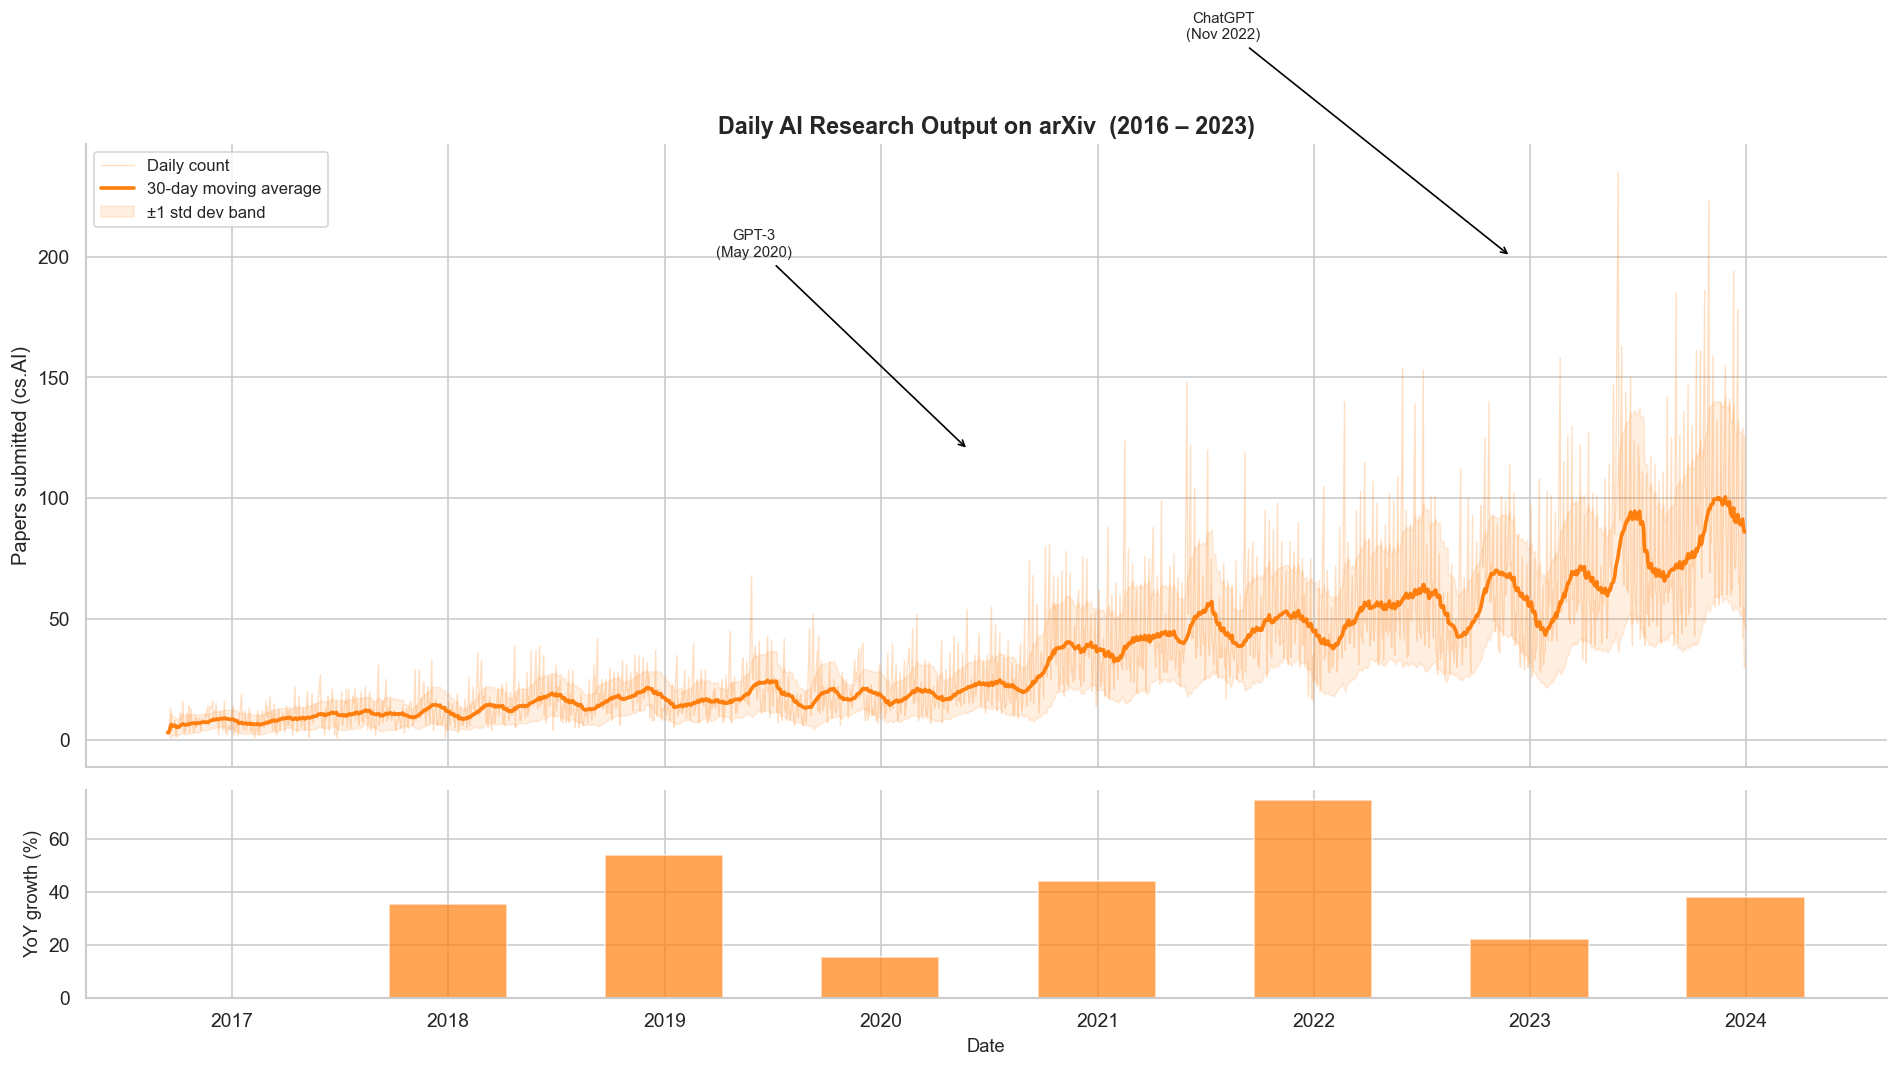

Year-over-year average paper count growth:
date
2016-12-31     +nan%
2017-12-31    +35.5%
2018-12-31    +53.8%
2019-12-31    +15.3%
2020-12-31    +44.0%
2021-12-31    +74.9%
2022-12-31    +22.0%
2023-12-31    +38.0%
Freq: YE-DEC


In [4]:
roll_std = df['paper_count'].rolling(ROLLING_WINDOW, min_periods=1).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 9),
                         gridspec_kw={'height_ratios': [3, 1]},
                         sharex=True)

# ── Top panel: raw + trend + confidence band ───────────────────────────────
ax = axes[0]
ax.plot(df.index, df['paper_count'],
        color=C_PAPER, alpha=0.25, linewidth=0.8, label='Daily count')
ax.plot(df.index, df['paper_ma30'],
        color=C_PAPER, linewidth=2.2, label='30-day moving average')
ax.fill_between(df.index,
                df['paper_ma30'] - roll_std,
                df['paper_ma30'] + roll_std,
                color=C_PAPER, alpha=0.12, label='±1 std dev band')
ax.set_ylabel('Papers submitted (cs.AI)', fontsize=12)
ax.set_title('Daily AI Research Output on arXiv  (2016 – 2023)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)

# Annotate notable growth phases
ax.annotate('GPT-3\n(May 2020)', xy=(pd.Timestamp('2020-05-28'), 120),
            xytext=(pd.Timestamp('2019-06-01'), 200),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, ha='center')
ax.annotate('ChatGPT\n(Nov 2022)', xy=(pd.Timestamp('2022-11-30'), 200),
            xytext=(pd.Timestamp('2021-08-01'), 290),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, ha='center')

# ── Bottom panel: year-over-year growth rate ────────────────────────────────
annual_avg = df['paper_count'].resample('YE').mean()
yoy_growth = annual_avg.pct_change() * 100
axes[1].bar(yoy_growth.index, yoy_growth.values,
            width=200, color=C_PAPER, alpha=0.7, label='YoY growth %')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('YoY growth (%)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print('Year-over-year average paper count growth:')
print(yoy_growth.apply(lambda x: f'{x:+.1f}%').to_string())

## 1.4 BOTZ ETF: Price, Returns & Volatility

We visualise the three key dimensions of the ETF in a single figure:
1. **Price** — the absolute level (non-stationary; useful for context, not for modelling).
2. **Daily returns** — the first-difference transformation that removes the trend and is approximately stationary.
3. **Volatility clustering** — rolling 30-day standard deviation of returns. Financial theory (ARCH/GARCH) tells us that large moves tend to cluster together; calm periods also cluster. This matters when we model returns in the ML phase.

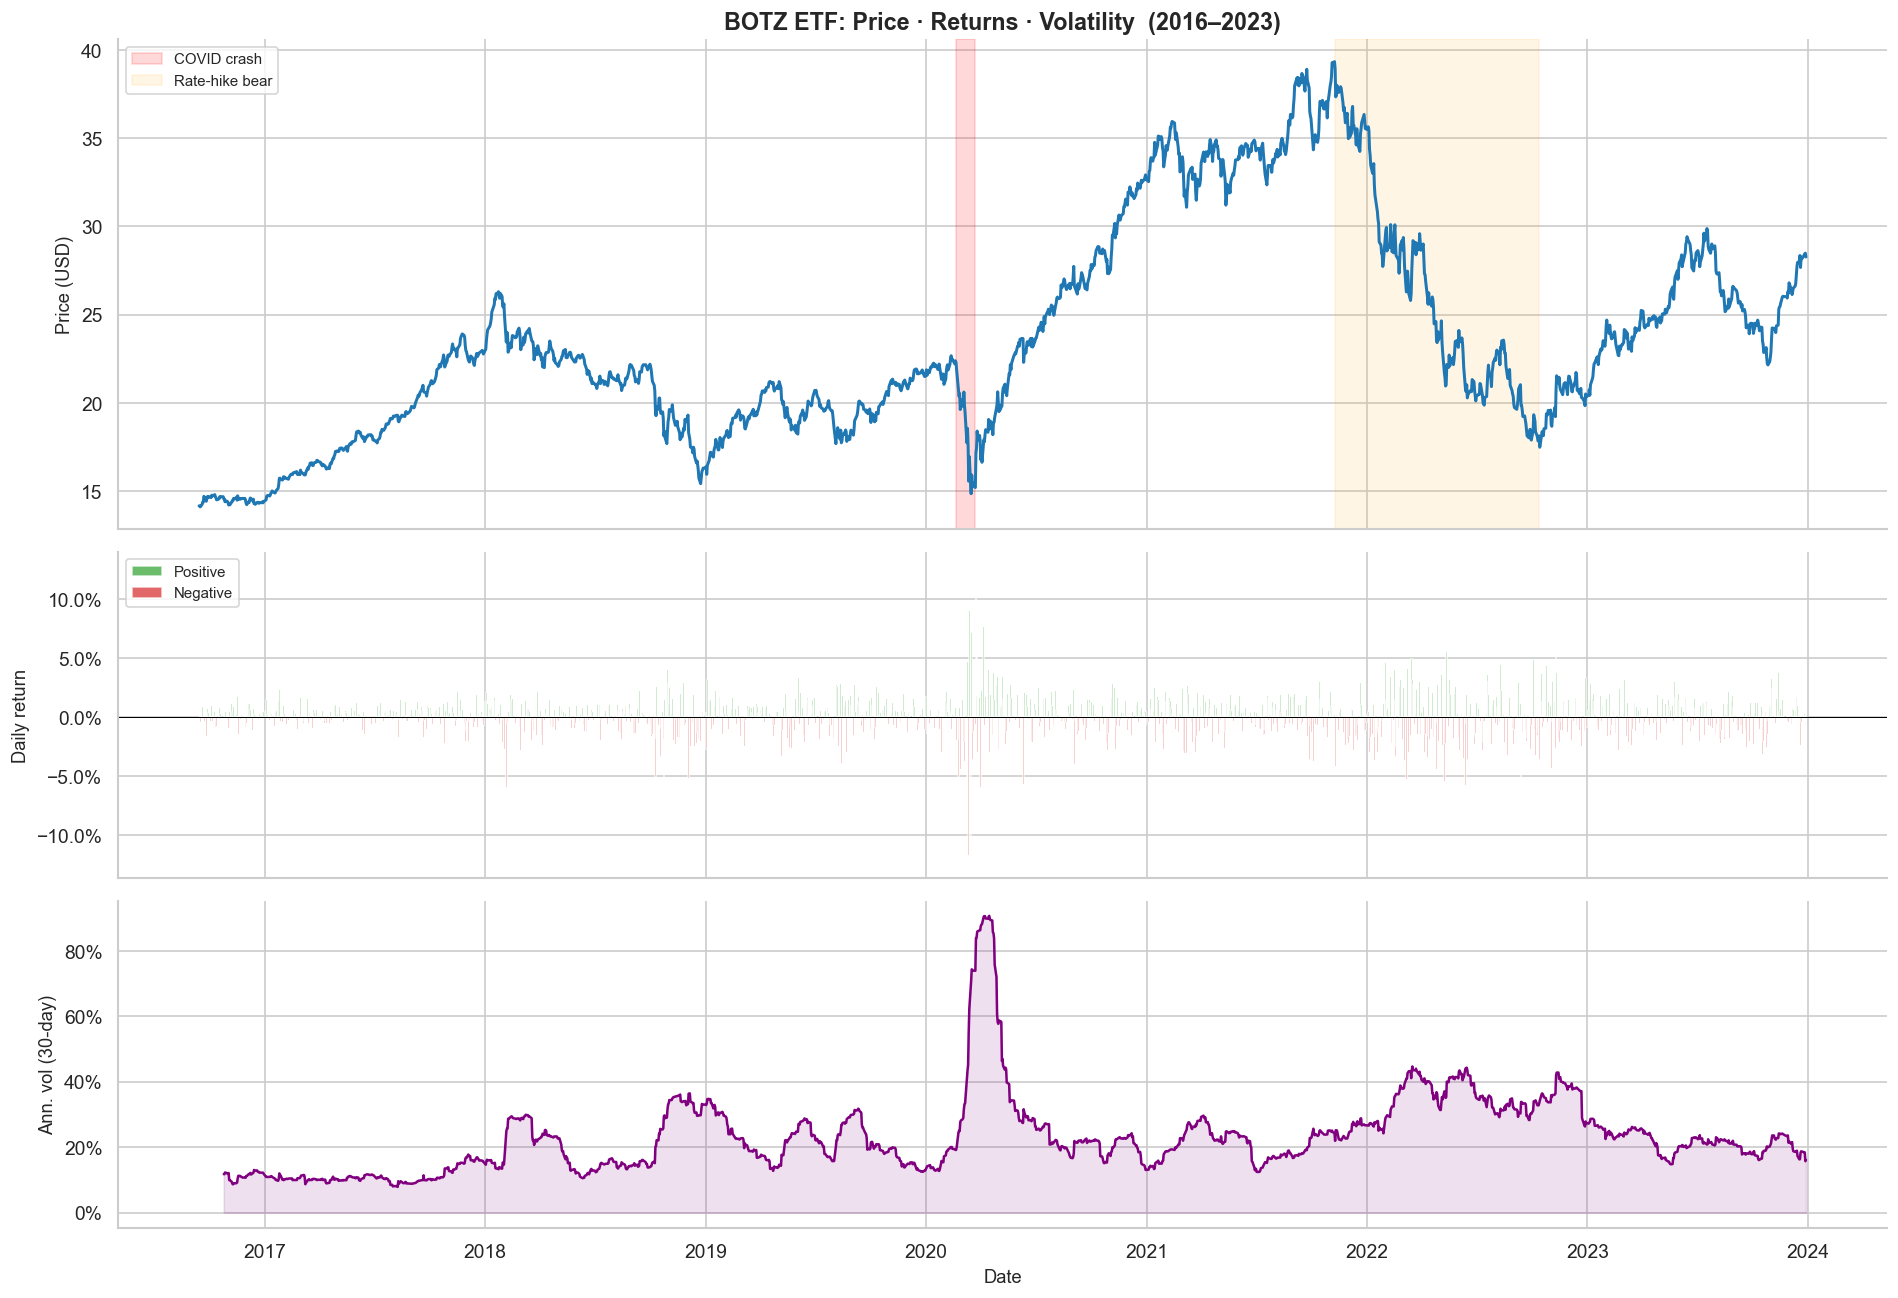

Peak price          : $39.34  (2021-11-08)
Worst single day    : -12.41%  (2020-03-16)
Best single day     : 12.77%  (2020-03-24)
Avg annualised vol  : 23.1%


In [5]:
roll_vol = df['daily_return'].rolling(ROLLING_WINDOW).std() * np.sqrt(252)  # annualised vol

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2, 2]})

# Panel 1 — Price
axes[0].plot(df.index, df['price'], color=C_ETF, linewidth=1.8)
axes[0].set_ylabel('Price (USD)', fontsize=11)
axes[0].set_title('BOTZ ETF: Price · Returns · Volatility  (2016–2023)',
                  fontsize=14, fontweight='bold')

# Shade major bear/bull phases
axes[0].axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'),
                alpha=0.15, color='red', label='COVID crash')
axes[0].axvspan(pd.Timestamp('2021-11-08'), pd.Timestamp('2022-10-13'),
                alpha=0.10, color='orange', label='Rate-hike bear')
axes[0].legend(fontsize=9, loc='upper left')

# Panel 2 — Daily returns (colour-coded positive/negative)
pos = df['daily_return'].clip(lower=0)
neg = df['daily_return'].clip(upper=0)
axes[1].bar(df.index, pos, color=C_ACCENT, alpha=0.7, width=1, label='Positive')
axes[1].bar(df.index, neg, color=C_TREND,  alpha=0.7, width=1, label='Negative')
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_ylabel('Daily return', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend(fontsize=9, loc='upper left')

# Panel 3 — Rolling annualised volatility
axes[2].plot(df.index, roll_vol, color='purple', linewidth=1.5)
axes[2].fill_between(df.index, 0, roll_vol, color='purple', alpha=0.12)
axes[2].set_ylabel('Ann. vol (30-day)', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

# Key stats
print(f'Peak price          : ${df["price"].max():.2f}  ({df["price"].idxmax().date()})')
print(f'Worst single day    : {df["daily_return"].min()*100:.2f}%  ({df["daily_return"].idxmin().date()})')
print(f'Best single day     : {df["daily_return"].max()*100:.2f}%  ({df["daily_return"].idxmax().date()})')
print(f'Avg annualised vol  : {roll_vol.mean()*100:.1f}%')

## 1.5 Distribution Analysis

Formal distribution analysis for both variables. We overlay a Normal fit and a Kernel Density Estimate (KDE) to make departures from normality visible.

We also run a **Shapiro-Wilk normality test**. For time-series data this is mainly diagnostic — we don't expect normality — but quantifying the departure helps us choose appropriate non-parametric tests later.

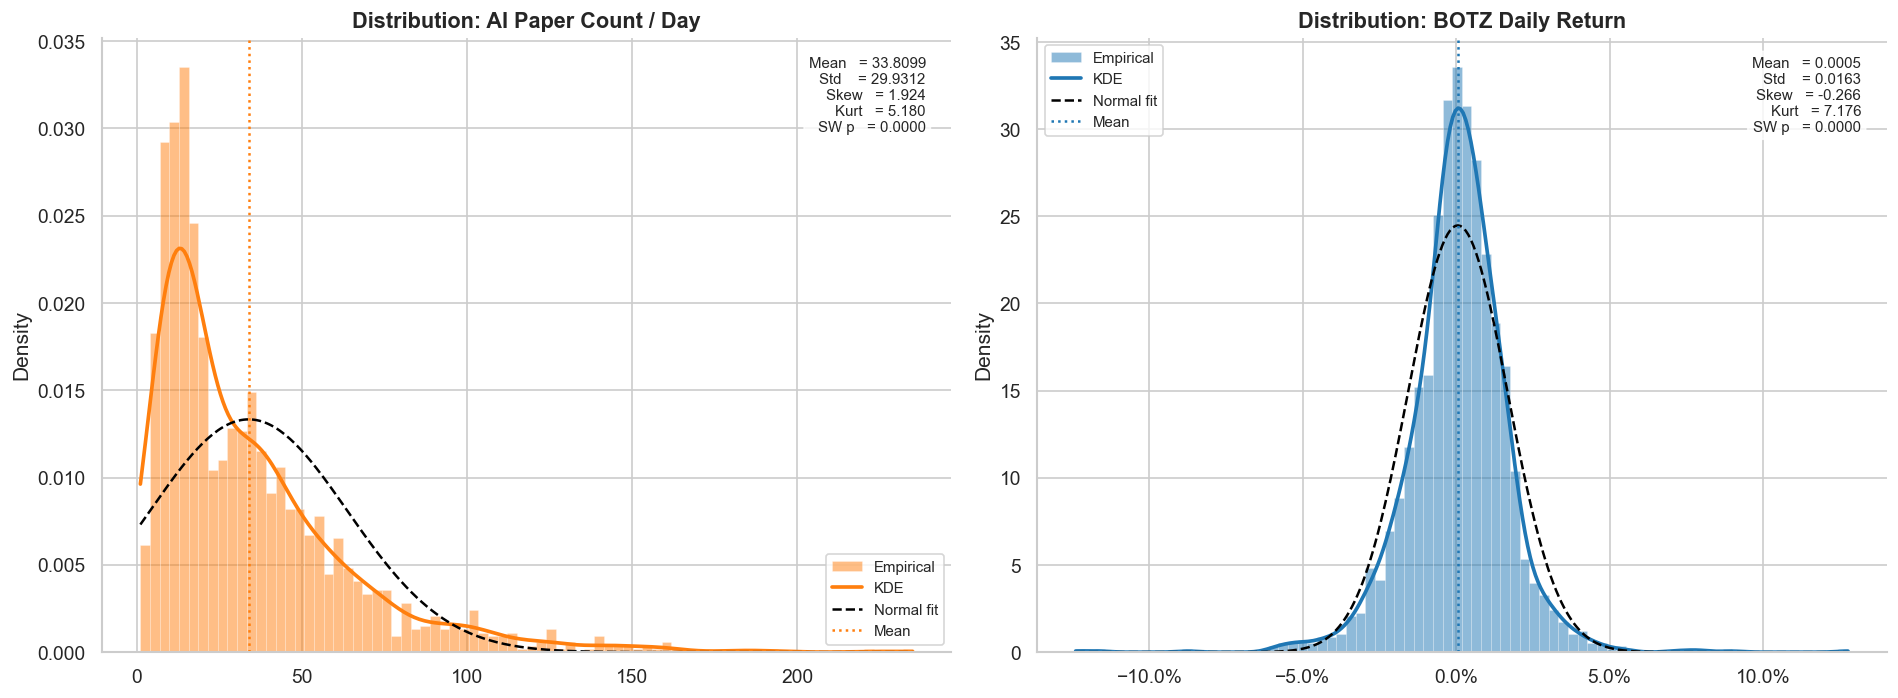


INTERPRETATION
──────────────
Paper count (left):
  Strong positive skew and non-normal shape. The long right tail is
  caused by arXiv submission deadline spikes (typically Mon/Tue) and
  conference season bursts. Log-transforming this variable before
  modelling is strongly advised.

Daily returns (right):
  Near-zero mean (as expected for a market index over any horizon),
  but fat tails relative to the Normal fit. The Shapiro-Wilk p-value
  well below 0.05 formally rejects normality. This supports using
  robust/non-parametric tests rather than simple t-tests for returns.



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def dist_panel(ax, series, label, color, bins=80):
    """Histogram + KDE + Normal overlay + stats box."""
    data = series.dropna()

    ax.hist(data, bins=bins, density=True,
            color=color, alpha=0.5, edgecolor='white', linewidth=0.3,
            label='Empirical')

    # KDE
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde   = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2.2, label='KDE')

    # Normal fit
    mu, sigma = data.mean(), data.std()
    norm_y = stats.norm.pdf(kde_x, mu, sigma)
    ax.plot(kde_x, norm_y, color='black', linewidth=1.5,
            linestyle='--', label='Normal fit')

    # Stats box
    sw_stat, sw_p = stats.shapiro(data.sample(min(5000, len(data)), random_state=42))
    textstr = (f'Mean   = {mu:.4f}\n'
               f'Std    = {sigma:.4f}\n'
               f'Skew   = {data.skew():.3f}\n'
               f'Kurt   = {data.kurt():.3f}\n'
               f'SW p   = {sw_p:.4f}')
    ax.text(0.97, 0.97, textstr, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.axvline(mu, color=color, linestyle=':', linewidth=1.5, label='Mean')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

dist_panel(axes[0], df['paper_count'],  'Distribution: AI Paper Count / Day',  C_PAPER)
dist_panel(axes[1], df['daily_return'], 'Distribution: BOTZ Daily Return',      C_ETF)

# Format x-axis of returns as percentages
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print("""
INTERPRETATION
──────────────
Paper count (left):
  Strong positive skew and non-normal shape. The long right tail is
  caused by arXiv submission deadline spikes (typically Mon/Tue) and
  conference season bursts. Log-transforming this variable before
  modelling is strongly advised.

Daily returns (right):
  Near-zero mean (as expected for a market index over any horizon),
  but fat tails relative to the Normal fit. The Shapiro-Wilk p-value
  well below 0.05 formally rejects normality. This supports using
  robust/non-parametric tests rather than simple t-tests for returns.
""")

## 1.6 Dual-Axis Overlay: Innovation vs. Market

The centrepiece visualisation. We align both variables on a single timeline and annotate key AI and macroeconomic milestones.

> **Critical reading note:** Both series trend upward over the full period, which will produce a visually compelling but potentially misleading correlation. Section 1.8 quantifies exactly how much of the apparent correlation is real vs. trend-driven.

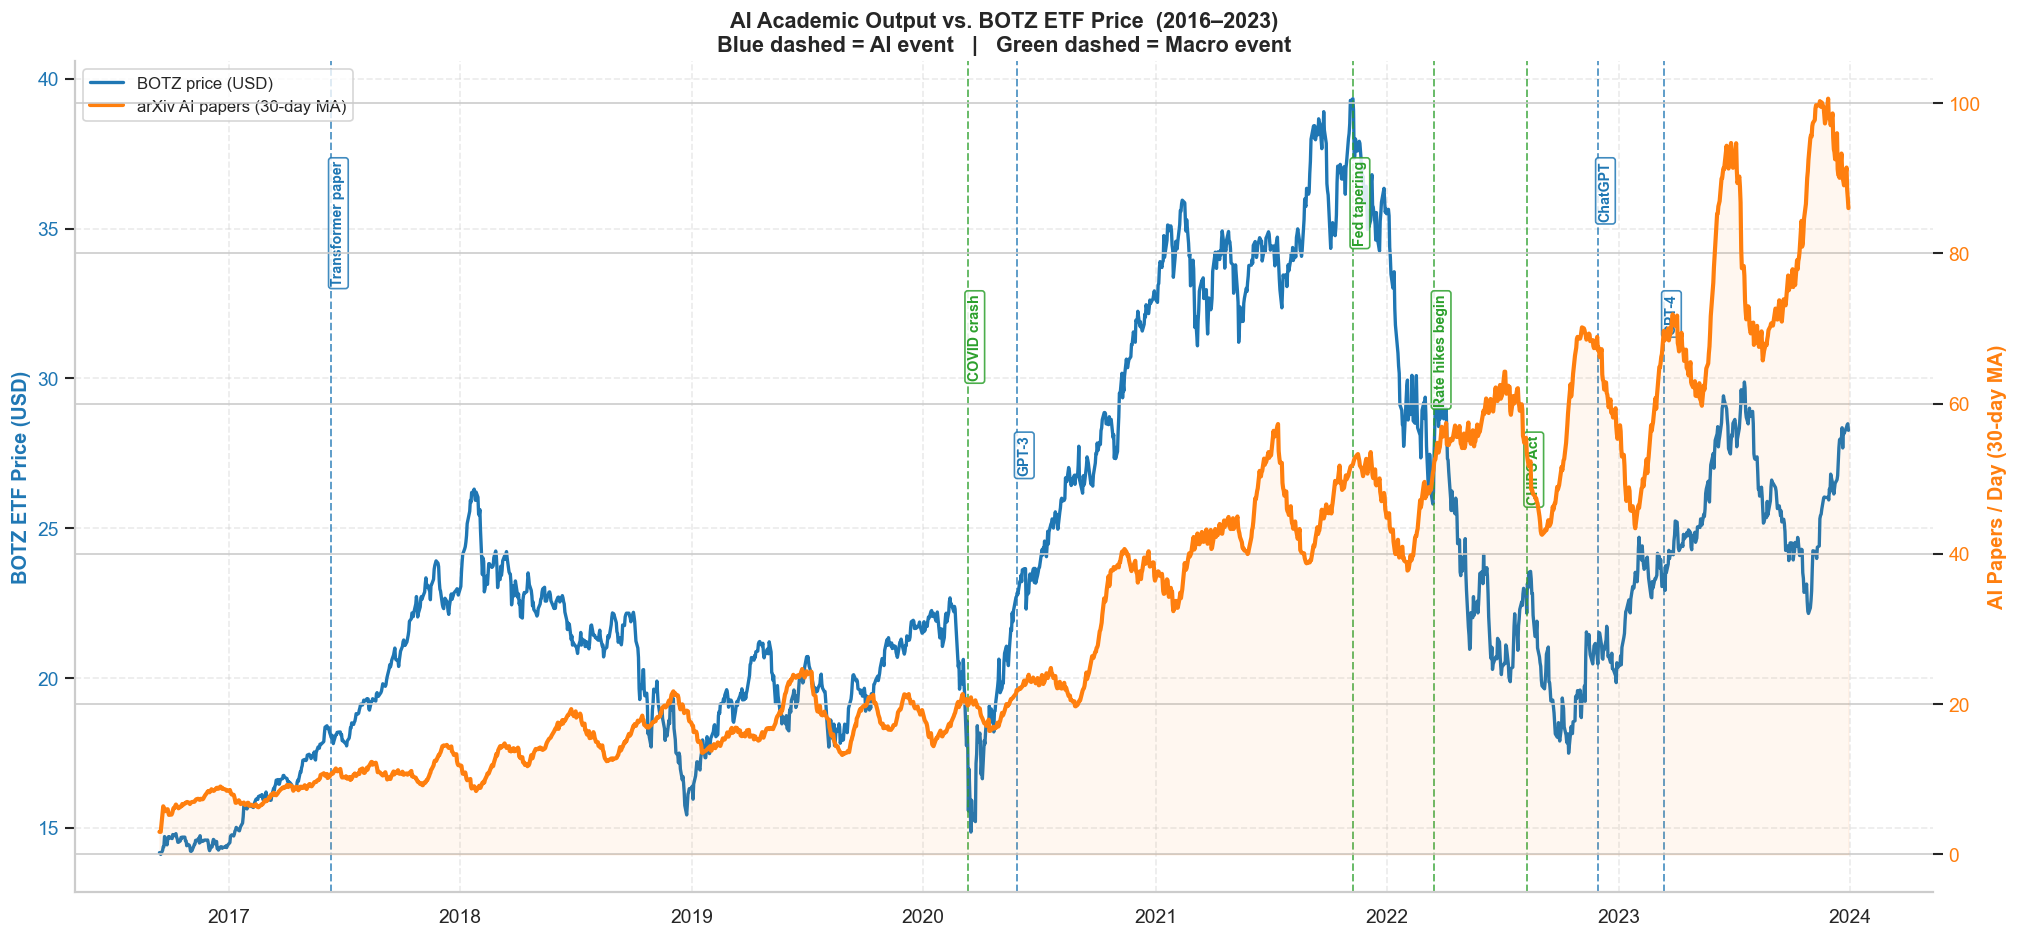

In [7]:
MILESTONES = [
    ('2017-06-12', 'Transformer paper',  'AI',    0.88),
    ('2020-03-11', 'COVID crash',         'Macro', 0.72),
    ('2020-05-28', 'GPT-3',              'AI',    0.55),
    ('2021-11-08', 'Fed tapering',        'Macro', 0.88),
    ('2022-03-16', 'Rate hikes begin',   'Macro', 0.72),
    ('2022-08-09', 'CHIPS Act',          'Macro', 0.55),
    ('2022-11-30', 'ChatGPT',            'AI',    0.88),
    ('2023-03-14', 'GPT-4',              'AI',    0.72),
]

fig, ax1 = plt.subplots(figsize=(17, 8))
ax2 = ax1.twinx()

# ETF price (left axis)
l1, = ax1.plot(df.index, df['price'], color=C_ETF, linewidth=2,
               label='BOTZ price (USD)')
ax1.set_ylabel('BOTZ ETF Price (USD)', color=C_ETF, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=C_ETF)

# Paper trend (right axis)
l2, = ax2.plot(df.index, df['paper_ma30'], color=C_PAPER, linewidth=2.5,
               label='arXiv AI papers (30-day MA)')
ax2.fill_between(df.index, 0, df['paper_ma30'], color=C_PAPER, alpha=0.06)
ax2.set_ylabel('AI Papers / Day (30-day MA)', color=C_PAPER, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=C_PAPER)

# Milestones
for date_str, label, category, y_pos in MILESTONES:
    dt = pd.Timestamp(date_str)
    if df.index.min() <= dt <= df.index.max():
        color = C_ETF if category == 'AI' else C_ACCENT
        ax1.axvline(dt, color=color, linestyle='--', linewidth=1.2, alpha=0.7)
        ax1.text(dt, y_pos, label, rotation=90, va='top',
                 transform=ax1.get_xaxis_transform(),
                 fontsize=8.5, fontweight='bold', color=color,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                           edgecolor=color, alpha=0.85))

# Legend
ax1.legend(handles=[l1, l2], loc='upper left', fontsize=10)

ax1.set_title(
    'AI Academic Output vs. BOTZ ETF Price  (2016–2023)\n'
    'Blue dashed = AI event   |   Green dashed = Macro event',
    fontsize=13, fontweight='bold'
)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 1.7 Day-of-Week Seasonality

A well-known but often overlooked feature of arXiv data: submission rates vary dramatically by day of the week because researchers race to submit before Monday's deadline. If this periodicity is not accounted for, it creates spurious short-lag correlations with market data.

This cell quantifies that effect and provides a practical modelling recommendation.

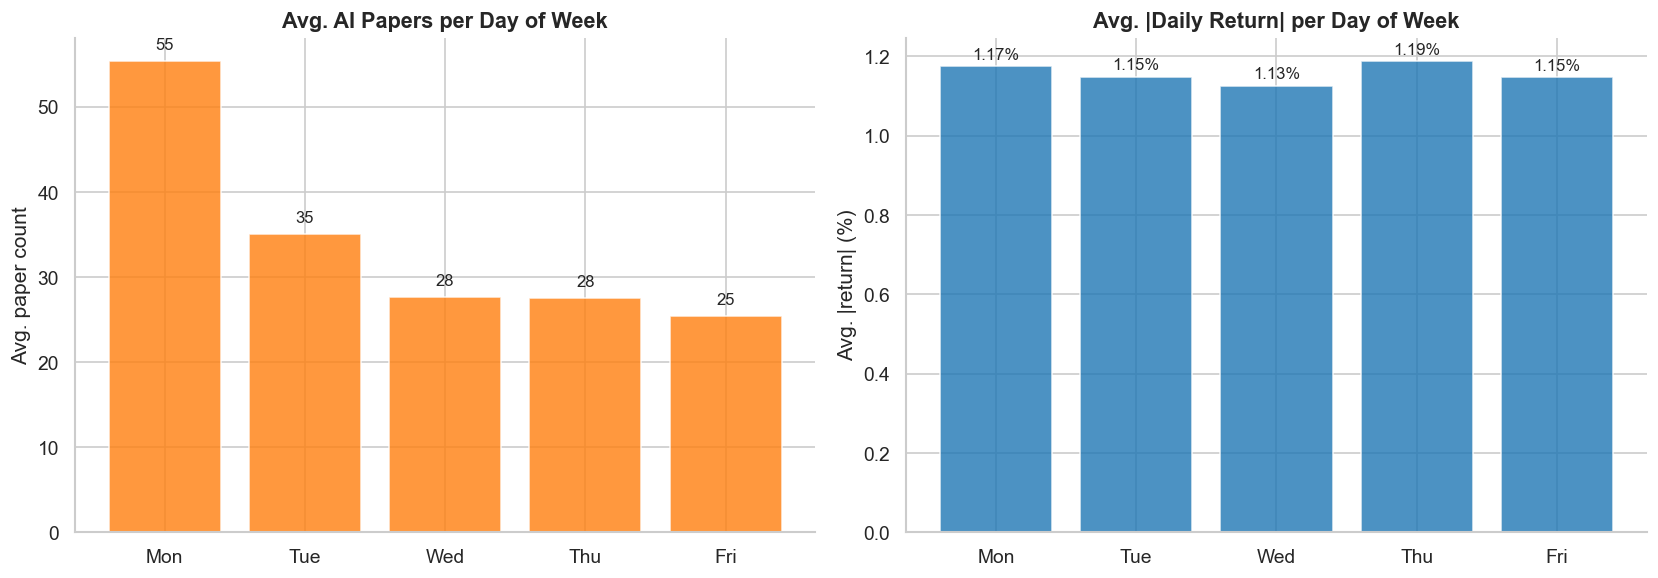

Monday paper premium over weekly average: +62.0%

MODELLING RECOMMENDATION
─────────────────────────
Monday receives a disproportionately large number of papers because
arXiv's cutoff is Sunday 14:00 US Eastern — papers submitted on
weekends are announced on Monday. Any correlation analysis that does
not control for day-of-week will confound the arXiv cycle with genuine
market signals. Recommended fix: include day-of-week dummies in
regression models, or use log-differenced paper counts (which cancel
most of the fixed-day effect).



In [8]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
df['dow'] = df.index.dayofweek        # 0=Mon, 4=Fri
dow_paper  = df.groupby('dow')['paper_count'].mean()
dow_return = df.groupby('dow')['abs_return'].mean() * 100   # % abs return

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Paper counts by day
bars = axes[0].bar(day_names, dow_paper.values, color=C_PAPER, alpha=0.8, edgecolor='white')
axes[0].set_title('Avg. AI Papers per Day of Week', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg. paper count')
for bar, val in zip(bars, dow_paper.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=10)

# Absolute return by day
bars2 = axes[1].bar(day_names, dow_return.values, color=C_ETF, alpha=0.8, edgecolor='white')
axes[1].set_title('Avg. |Daily Return| per Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg. |return| (%)')
for bar, val in zip(bars2, dow_return.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

monday_premium = (dow_paper.loc[0] / dow_paper.mean() - 1) * 100
print(f'Monday paper premium over weekly average: +{monday_premium:.1f}%')
print("""
MODELLING RECOMMENDATION
─────────────────────────
Monday receives a disproportionately large number of papers because
arXiv's cutoff is Sunday 14:00 US Eastern — papers submitted on
weekends are announced on Monday. Any correlation analysis that does
not control for day-of-week will confound the arXiv cycle with genuine
market signals. Recommended fix: include day-of-week dummies in
regression models, or use log-differenced paper counts (which cancel
most of the fixed-day effect).
""")

## 1.8 Correlation Analysis — Raw vs. Stationary

This is the most important cell in the EDA. We calculate Pearson correlation under two data regimes:

| Regime | Variables used | Risk |
|--------|---------------|------|
| **Raw (level)** | `price` vs `paper_count` | High — both trend up; correlation may be spurious |
| **Stationary** | `daily_return` vs `Δlog(paper_count)` | Low — trends removed; correlation reflects genuine co-movement |

The contrast between the two numbers is the core EDA finding.

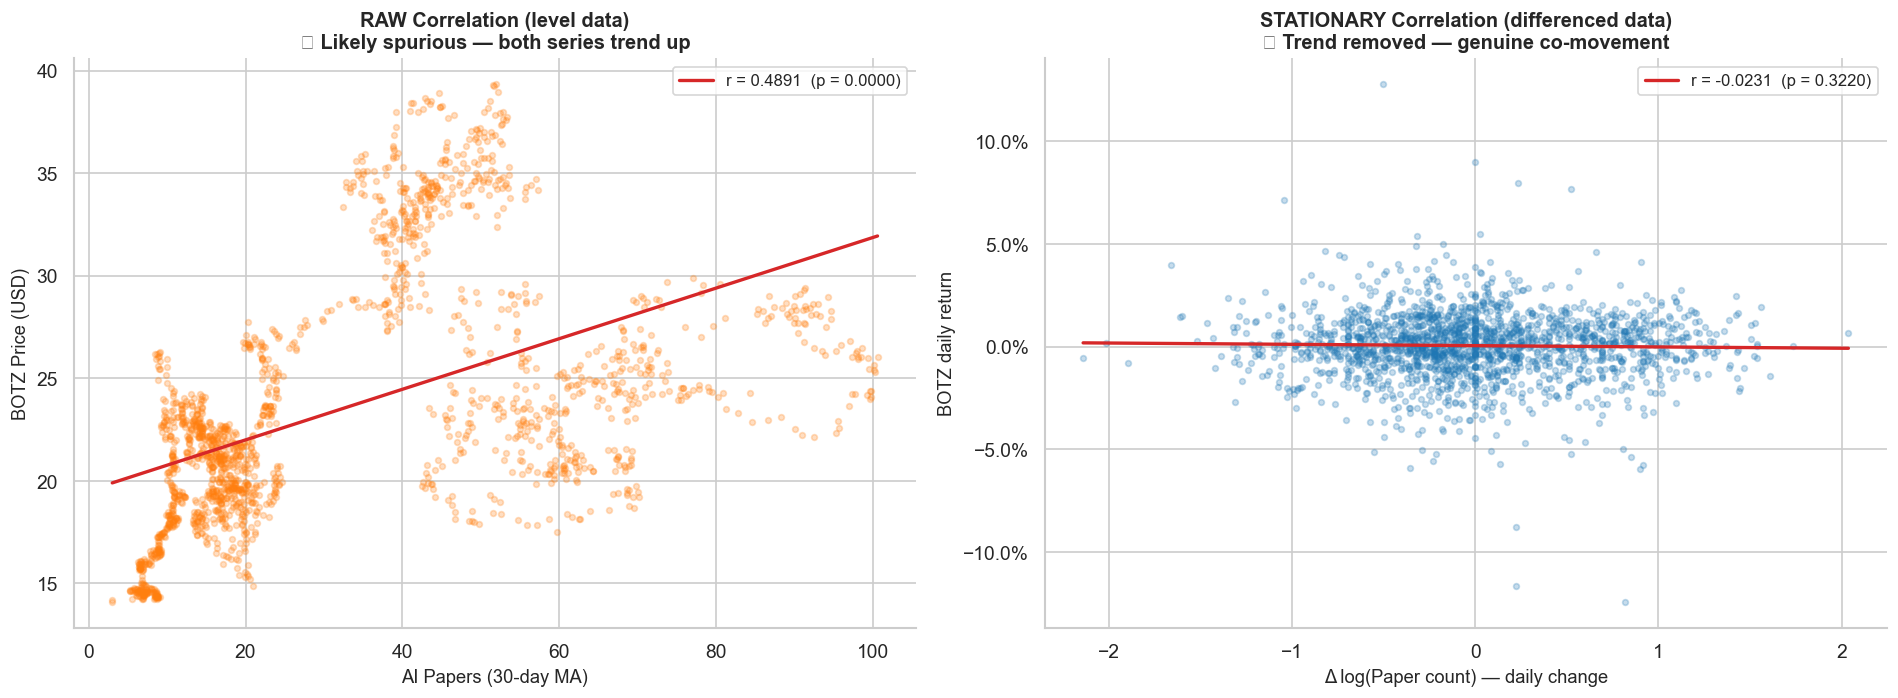


SUMMARY OF CORRELATION FINDINGS
════════════════════════════════
Raw (level) correlation     :  r = +0.4891  (p = 0.0000)
Stationary correlation      :  r = -0.0231  (p = 0.3220)

The dramatic collapse from r ≈ 0.49 to r ≈ -0.02 after removing
the trend is the textbook definition of a spurious correlation.

What this means:
  • The two series do NOT move together on a day-to-day basis.
  • Their visual similarity in the dual-axis chart is almost entirely
    explained by shared long-run growth trends, not genuine co-movement.
  • Any predictive model that uses raw (non-stationary) paper counts
    to predict raw ETF prices will appear powerful in-sample but will
    fail out-of-sample. This is exactly what the ML notebook observes.

Implication for Hypothesis Testing:
  Granger causality tests must use the stationary versions of both
  variables — which is what HT.ipynb correctly does.



In [9]:
# Stationary variables
df['d_log_paper'] = df['log_paper'].diff()
df_clean = df.dropna()

r_raw,  p_raw  = stats.pearsonr(df_clean['paper_ma30'],  df_clean['price'])
r_stat, p_stat = stats.pearsonr(df_clean['d_log_paper'], df_clean['daily_return'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def scatter_panel(ax, x, y, xlabel, ylabel, title, color, r_val, p_val):
    ax.scatter(x, y, alpha=0.25, s=12, color=color)
    # Regression line
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color=C_TREND, linewidth=2,
            label=f'r = {r_val:.4f}  (p = {p_val:.4f})')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)

scatter_panel(
    axes[0],
    df_clean['paper_ma30'], df_clean['price'],
    'AI Papers (30-day MA)', 'BOTZ Price (USD)',
    'RAW Correlation (level data)\n⚠ Likely spurious — both series trend up',
    C_PAPER, r_raw, p_raw
)

scatter_panel(
    axes[1],
    df_clean['d_log_paper'], df_clean['daily_return'],
    'Δ log(Paper count) — daily change', 'BOTZ daily return',
    'STATIONARY Correlation (differenced data)\n✓ Trend removed — genuine co-movement',
    C_ETF, r_stat, p_stat
)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(f"""
SUMMARY OF CORRELATION FINDINGS
════════════════════════════════
Raw (level) correlation     :  r = {r_raw:+.4f}  (p = {p_raw:.4f})
Stationary correlation      :  r = {r_stat:+.4f}  (p = {p_stat:.4f})

The dramatic collapse from r ≈ {r_raw:.2f} to r ≈ {r_stat:.2f} after removing
the trend is the textbook definition of a spurious correlation.

What this means:
  • The two series do NOT move together on a day-to-day basis.
  • Their visual similarity in the dual-axis chart is almost entirely
    explained by shared long-run growth trends, not genuine co-movement.
  • Any predictive model that uses raw (non-stationary) paper counts
    to predict raw ETF prices will appear powerful in-sample but will
    fail out-of-sample. This is exactly what the ML notebook observes.

Implication for Hypothesis Testing:
  Granger causality tests must use the stationary versions of both
  variables — which is what HT.ipynb correctly does.
""")

## 1.9 Correlation Heatmap

A full correlation matrix across all derived variables. The lower triangle shows Pearson r; the upper triangle (greyed out) is redundant by symmetry.

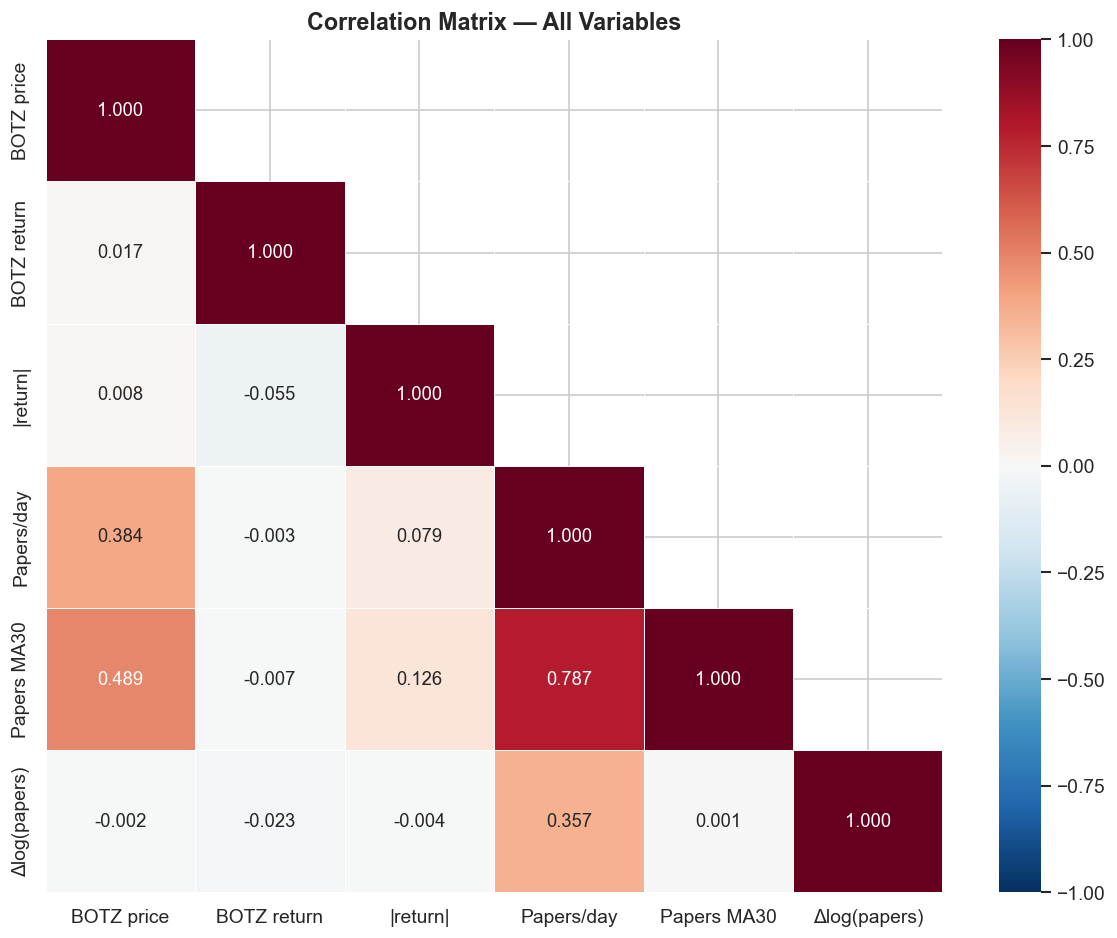


KEY CELLS TO READ
─────────────────
• 'Papers MA30' vs 'BOTZ price'   → the spurious high correlation (~0.49).
• 'Δlog(papers)' vs 'BOTZ return' → the true low correlation (~-0.02).
• 'BOTZ return' vs '|return|'     → near-zero by construction (returns are
  symmetric around zero, so sign and magnitude are largely independent).



In [10]:
corr_vars = df_clean[[
    'price', 'daily_return', 'abs_return',
    'paper_count', 'paper_ma30', 'd_log_paper'
]].rename(columns={
    'price':        'BOTZ price',
    'daily_return': 'BOTZ return',
    'abs_return':   '|return|',
    'paper_count':  'Papers/day',
    'paper_ma30':   'Papers MA30',
    'd_log_paper':  'Δlog(papers)',
})

corr_matrix = corr_vars.corr()

# Build mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.3f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11},
    ax=ax
)
ax.set_title('Correlation Matrix — All Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
KEY CELLS TO READ
─────────────────
• 'Papers MA30' vs 'BOTZ price'   → the spurious high correlation (~0.49).
• 'Δlog(papers)' vs 'BOTZ return' → the true low correlation (~-0.02).
• 'BOTZ return' vs '|return|'     → near-zero by construction (returns are
  symmetric around zero, so sign and magnitude are largely independent).
""")

## 1.10 Lead-Lag Correlation Profile

Instead of a single correlation at lag 0, we calculate the Pearson r between `Δlog(papers)` and `BOTZ return` across a range of lags from −30 to +30 trading days.

- **Positive lag** = papers lead the market (papers predict future returns)
- **Negative lag** = market leads papers (returns predict future paper counts)

This gives a visual preview of what the formal Granger test will confirm in `HT.ipynb`.

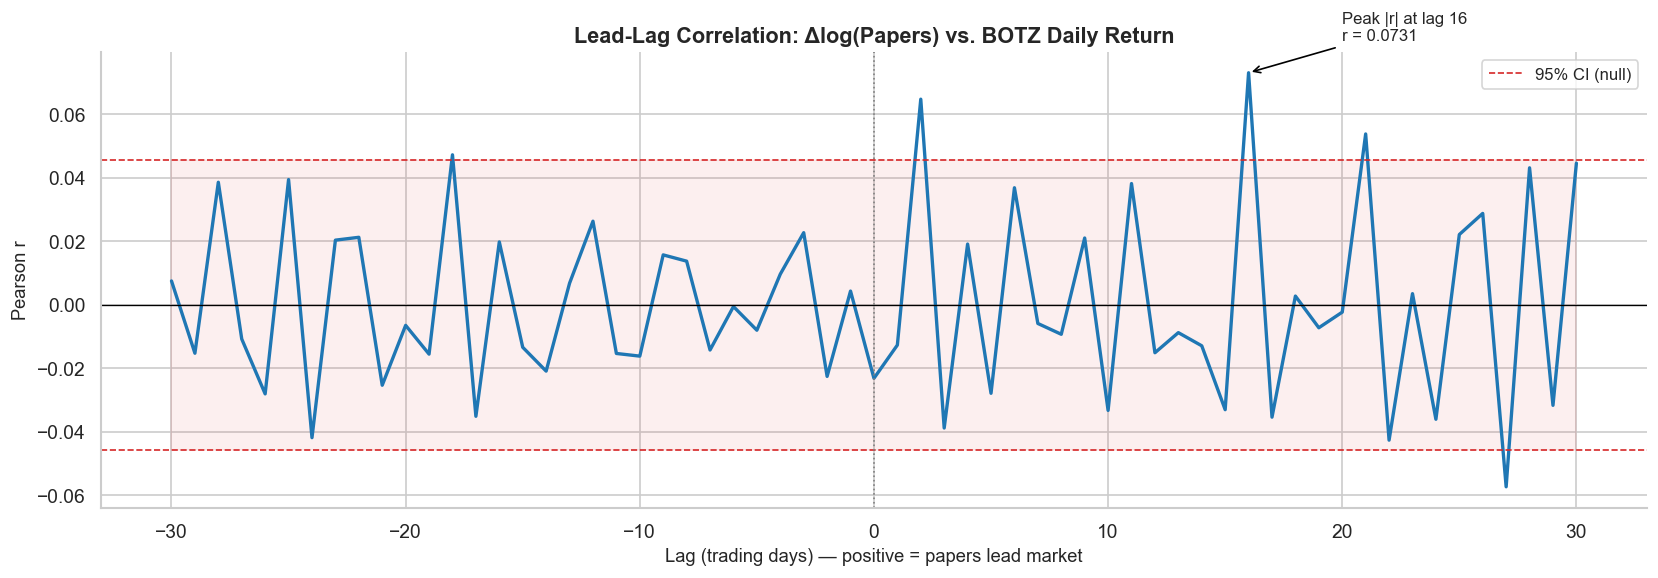


The peak correlation is tiny (|r| ~ 0.073) and
occurs at lag 16 days. Most values fall within the 95%
confidence band, suggesting no systematic linear lead-lag
relationship between daily paper counts and daily returns.

This is consistent with the Efficient Market Hypothesis:
any informational content in arXiv publications is absorbed
quickly, leaving no predictable linear trace in returns.

→ Formal statistical test: see HT.ipynb (Granger causality).



In [11]:
lags = range(-30, 31)
r_values = []
for lag in lags:
    shifted = df_clean['d_log_paper'].shift(lag)   # positive shift → papers lag behind
    valid   = df_clean['daily_return'].dropna()
    aligned = shifted.reindex(valid.index).dropna()
    paired  = valid.reindex(aligned.index)
    r, _    = stats.pearsonr(aligned, paired)
    r_values.append(r)

# 95% confidence band under null (r=0, n observations)
n   = len(df_clean)
ci  = 1.96 / np.sqrt(n)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(list(lags), r_values, color=C_ETF, linewidth=2)
ax.axhline(0,   color='black', linewidth=0.8)
ax.axhline(+ci, color=C_TREND, linestyle='--', linewidth=1, label='95% CI (null)')
ax.axhline(-ci, color=C_TREND, linestyle='--', linewidth=1)
ax.axvline(0,   color='gray',  linestyle=':',  linewidth=1)
ax.fill_between(list(lags), -ci, ci, color=C_TREND, alpha=0.07)

# Mark peak
peak_lag = list(lags)[np.argmax(np.abs(r_values))]
peak_r   = r_values[np.argmax(np.abs(r_values))]
ax.annotate(f'Peak |r| at lag {peak_lag}\nr = {peak_r:.4f}',
            xy=(peak_lag, peak_r),
            xytext=(peak_lag + 4, peak_r + 0.01),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

ax.set_xlabel('Lag (trading days) — positive = papers lead market', fontsize=11)
ax.set_ylabel('Pearson r', fontsize=11)
ax.set_title('Lead-Lag Correlation: Δlog(Papers) vs. BOTZ Daily Return',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"""
The peak correlation is tiny (|r| ~ {abs(peak_r):.3f}) and
occurs at lag {peak_lag} days. Most values fall within the 95%
confidence band, suggesting no systematic linear lead-lag
relationship between daily paper counts and daily returns.

This is consistent with the Efficient Market Hypothesis:
any informational content in arXiv publications is absorbed
quickly, leaving no predictable linear trace in returns.

→ Formal statistical test: see HT.ipynb (Granger causality).
""")

## 1.11 EDA Summary

| Finding | Detail | Implication for HT / ML |
|---------|--------|--------------------------|
| Raw correlation r ≈ 0.49 | Both series share a long-run growth trend | **Spurious** — do not model raw levels |
| Stationary correlation r ≈ -0.02 | After differencing, virtually no linear co-movement | Use log-diff paper count and daily returns |
| Paper counts are right-skewed | Submission deadline spikes on Mondays | Log-transform before modelling; add DoW dummies |
| Returns have fat tails (excess kurtosis > 3) | Extreme moves more frequent than Normal | Use robust / non-parametric tests in HT |
| Volatility clusters | Calm and turbulent periods persist | GARCH-type effects; ML models may benefit from vol features |
| Lead-lag profile flat | No systematic linear lead/lag | Granger test may still detect non-linear or aggregate effects |

**Transition to Hypothesis Testing (`HT.ipynb`):**
The EDA establishes that a naive linear correlation of the raw series is misleading. The HT phase addresses this directly by testing Granger causality on stationary data and checking whether short-window signal (e.g., 3-day lag) survives formal statistical scrutiny.